In [3]:
import pandas as pd
import seaborn as sns

In [ ]:
titanic = sns.load_dataset('titanic') 
 titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print(titanic.info()) 
print(titanic.isnull().sum() ) 
print(titanic.describe())  

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
survived         0
pclass           0
sex              0
age            177
sibsp        

In [6]:
  titanic = titanic.drop(columns=['deck'])

In [7]:
 titanic['age'] = titanic['age'].fillna(titanic['age'].median()) 

In [8]:
 titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0]) 

In [9]:
 titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [10]:
titanic = titanic.drop(columns = ['embark_town'])

In [11]:
titanic.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [12]:
titanic.duplicated().sum()
titanic[titanic.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
47,1,3,female,28.0,0,0,7.7500,Q,Third,woman,False,yes,True
55,1,1,male,28.0,0,0,35.5000,S,First,man,True,yes,True
76,0,3,male,28.0,0,0,7.8958,S,Third,man,True,no,True
77,0,3,male,28.0,0,0,8.0500,S,Third,man,True,no,True
87,0,3,male,28.0,0,0,8.0500,S,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,no,True
878,0,3,male,28.0,0,0,7.8958,S,Third,man,True,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,no,True


In [13]:
titanic = titanic.drop_duplicates()

In [14]:
titanic.duplicated().sum()

np.int64(0)

In [15]:
def clean_titanic(df):
    df = df.drop(columns=["deck", "embark_town"])
    df["age"] = df["age"].fillna(df["age"].median())
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df = df.drop_duplicates()
    return df

In [16]:
titanic_brut = sns.load_dataset('titanic') 
titanic_propre = clean_titanic(titanic_brut)
titanic_propre.isnull().sum() 

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

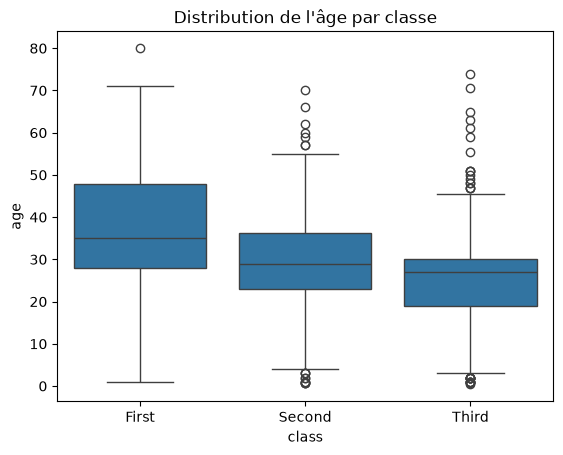

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation de la distribution de l'âge par classe
sns.boxplot(x="class", y="age", data=titanic)
plt.title("Distribution de l'âge par classe")
plt.show()

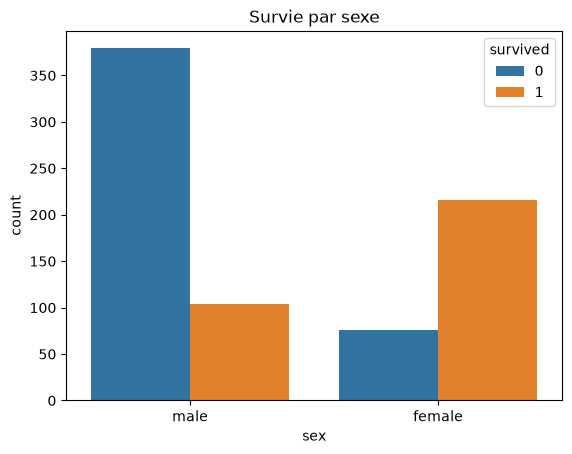

In [18]:
sns.countplot(x='sex', hue='survived', data=titanic) 
plt.title('Survie par sexe') 
plt.show()

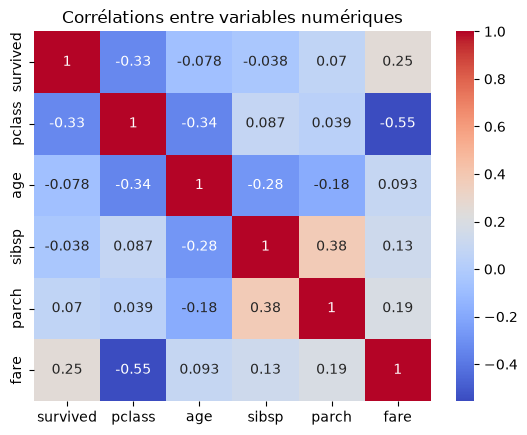

In [19]:
numeric_cols = titanic.select_dtypes(include='number') 
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm') 
plt.title('Corrélations entre variables numériques') 
plt.show()

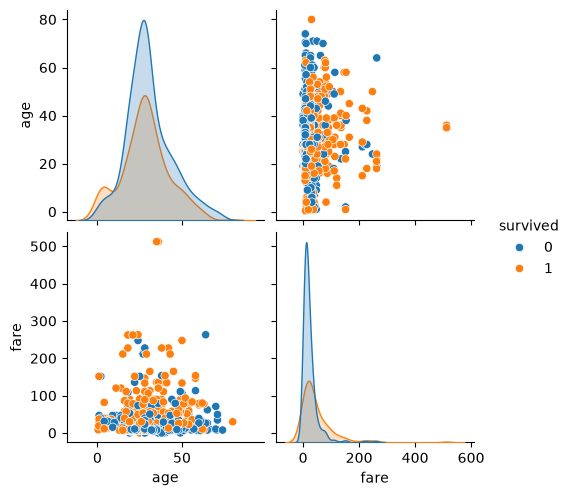

In [20]:
sns.pairplot(titanic, vars=['age', 'fare'], hue='survived') 
plt.show()

In [21]:
titanic.groupby('survived')['fare'].mean()

survived
0    24.022499
1    50.314142
Name: fare, dtype: float64

 ## Conclusions de l'analyse exploratoire — Titanic
### Contexte Analyse du dataset Titanic (891 passagers) pour identifier les facteurs liés à la survie.

### Résultats clés
 1. **Classe et âge** : les passagers de 1ère classe sont en médiane plus âgés que ceux de 3ème classe. 
 2. **Sexe et survie** : les femmes ont un taux de survie nettement supérieur aux hommes. 
 3. **Facteurs les plus liés à la survie** : la classe (pclass, corrélation -0.33) et le prix du billet (fare, corrélation 0.25) sont les variables numériques les plus corrélées à la survie. 
 4. **Prix du billet et survie** : les survivants ont payé en moyenne 50€ contre 24€ pour les non-survivants, soit plus du double.

 ### Conclusion
  La survie sur le Titanic n'était pas aléatoire : elle reflète des priorités d'évacuation (femmes/enfants d'abord) et des inégalités socio-économiques (accès privilégié aux canots pour les passagers de 1ère classe). Ces variables (sexe, classe, prix du billet) seront de bons candidats comme features pour un futur modèle de prédiction.